# UNet (Supervised Baseline)
Fully supervised U-Net trained from scratch across multiple label fractions.
No pretraining stage — serves as the baseline for comparison with BT-UNet and SimSiam-UNet.

**Pipeline:**
1. Load KDSB data (cached `.npy` arrays if available)
2. For each label fraction (5%, 10%, 20%, 50%): build a fresh U-Net, train, evaluate, save


## Configuration

In [9]:
# ============================================================
# CONFIGURATION
# ============================================================

TRAIN_PATH   = "KDSB/train/"
TEST_PATH    = "KDSB/test/"
SAVE_DIR     = "saved_models"
SAVE_NP      = "saved_np"
DATASET_NAME = "KDSB"

IMG_HEIGHT   = 256
IMG_WIDTH    = 256
IMG_CHANNELS = 3

# Label fractions to sweep
LABEL_FRACTIONS = [0.05, 0.10, 0.20, 0.50]

val_split  = 0.3
THRESHOLD  = 0.5

# Training
FINETUNE_EPOCHS = 200
FINETUNE_BATCH  = 8
TRAIN_FLG       = True   # False = load saved weights, skip training

# TEST_MODE: set True to smoke-test the full pipeline cheaply
TEST_MODE = False

## Imports

In [3]:
import os
import datetime
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from skimage.io import imread, imshow
from skimage.morphology import label
from skimage.transform import resize

import tensorflow as tf
from tensorflow.keras import layers, backend as K
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, CSVLogger, TensorBoard
)
from tensorflow.keras.metrics import Accuracy, Precision, Recall, MeanIoU, MeanAbsoluteError
from tensorflow.keras.losses import binary_crossentropy
from hausdorff import hausdorff_distance

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(SAVE_NP,  exist_ok=True)
os.makedirs("logs/fit", exist_ok=True)

## Data Loading

In [4]:
x_train_path = os.path.join(SAVE_NP, f"{DATASET_NAME}_X_train_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
y_train_path = os.path.join(SAVE_NP, f"{DATASET_NAME}_Y_train_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
x_test_path  = os.path.join(SAVE_NP, f"{DATASET_NAME}_X_test_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
y_test_path  = os.path.join(SAVE_NP, f"{DATASET_NAME}_Y_test_{IMG_HEIGHT}x{IMG_WIDTH}.npy")

if all(os.path.exists(p) for p in [x_train_path, y_train_path, x_test_path, y_test_path]):
    print("Found cached arrays, loading...")
    X_train = np.load(x_train_path)
    Y_train = np.load(y_train_path)
    X_test  = np.load(x_test_path)
    Y_test  = np.load(y_test_path)
    print(f"Loaded — Train: {X_train.shape}, Test: {X_test.shape}")

else:
    print("No cached arrays found, loading and resizing from disk...")
    train_ids = next(os.walk(TRAIN_PATH + 'org/'))[2][:]
    test_ids  = next(os.walk(TEST_PATH  + 'org/'))[2][:]
    print(f"Train images: {len(train_ids)}, Test images: {len(test_ids)}")

    X_train = np.zeros((len(train_ids), IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.float32)
    Y_train = np.zeros((len(train_ids), IMG_HEIGHT, IMG_WIDTH, 1),            dtype=np.float32)
    X_test  = np.zeros((len(test_ids),  IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.float32)
    Y_test  = np.zeros((len(test_ids),  IMG_HEIGHT, IMG_WIDTH, 1),            dtype=np.float32)

    for n, id_ in tqdm(enumerate(train_ids), total=len(train_ids)):
        img = imread(TRAIN_PATH + 'org/' + id_)[:, :, :IMG_CHANNELS]
        img = resize(img, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
        X_train[n] = img
        mask = imread(TRAIN_PATH + 'gt/' + id_[:-4] + '_GT.png')
        mask = np.expand_dims(mask, axis=-1)
        mask = resize(mask, (IMG_HEIGHT, IMG_WIDTH, 1), mode='constant', preserve_range=True)
        Y_train[n][mask[:, :, 0] / 255 > 0.] = 1.

    for n, id_ in tqdm(enumerate(test_ids), total=len(test_ids)):
        img = imread(TEST_PATH + 'org/' + id_)[:, :, :IMG_CHANNELS]
        img = resize(img, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
        X_test[n] = img
        mask = imread(TEST_PATH + 'gt/' + id_[:-4] + '_GT.png')
        mask = np.expand_dims(mask, axis=-1)
        mask = resize(mask, (IMG_HEIGHT, IMG_WIDTH, 1), mode='constant', preserve_range=True)
        Y_test[n][mask[:, :, 0] / 255 > 0.] = 1.

    np.save(x_train_path, X_train)
    np.save(y_train_path, Y_train)
    np.save(x_test_path,  X_test)
    np.save(y_test_path,  Y_test)
    print(f"Saved — Train: {X_train.shape}, Test: {X_test.shape}")

Found cached arrays, loading...
Loaded — Train: (2594, 256, 256, 3), Test: (1000, 256, 256, 3)


## U-Net Architecture
Identical to BT-UNet and SimSiam-UNet notebooks.

In [5]:
def double_conv_layer(x, filter_size, size, dropout, batch_norm=False):
    axis = 3
    conv = SeparableConv2D(size, (filter_size, filter_size), padding='same')(x)
    if batch_norm:
        conv = BatchNormalization(axis=axis)(conv)
    conv = Activation('relu')(conv)
    conv = SeparableConv2D(size, (filter_size, filter_size), padding='same')(conv)
    if batch_norm:
        conv = BatchNormalization(axis=axis)(conv)
    conv = Activation('relu')(conv)
    if dropout > 0:
        conv = Dropout(dropout)(conv)
    shortcut = Conv2D(size, kernel_size=(1, 1), padding='same')(x)
    if batch_norm:
        shortcut = BatchNormalization(axis=axis)(shortcut)
    return add([shortcut, conv])

def encoder(inputs):
    num_filters = [16, 32, 64, 128]
    skip_connections = []
    x = inputs
    for f in num_filters:
        a = double_conv_layer(x, 3, f, 0.1, True)
        skip_connections.append(a)
        x = MaxPooling2D(pool_size=(2, 2))(a)
    return x, skip_connections

def bottleneck(inputs):
    return double_conv_layer(inputs, 3, 256, 0.1, True)

def decoder(inputs, skip_connections):
    num_filters = [128, 64, 32, 16]
    skip_connections = skip_connections[::-1]
    x = inputs
    for i, f in enumerate(num_filters):
        x_up  = UpSampling2D(size=(2, 2), data_format="channels_last")(x)
        x_att = concatenate([x_up, skip_connections[i]], axis=-1)
        x     = double_conv_layer(x_att, 3, f, 0.1, True)
    return x

def output_layer(inputs):
    x = Conv2D(1, kernel_size=(1, 1))(inputs)
    x = BatchNormalization()(x)
    x = Activation('sigmoid')(x)
    return x

def build_unet(name="unet"):
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    s      = layers.Rescaling(1.0 / 255)(inputs)
    x, skips = encoder(s)
    x        = bottleneck(x)
    x        = decoder(x, skips)
    outputs  = output_layer(x)
    return Model(inputs, outputs, name=name)

## Metrics
Identical to BT-UNet and SimSiam-UNet notebooks.

In [10]:
def iou_metric(y_true_in, y_pred_in):
    labels       = label(y_true_in > 0.5)
    y_pred       = label(y_pred_in > 0.5)
    true_objects = len(np.unique(labels))
    pred_objects = len(np.unique(y_pred))
    intersection = np.histogram2d(labels.flatten(), y_pred.flatten(),
                                  bins=(true_objects, pred_objects))[0]
    area_true    = np.expand_dims(np.histogram(labels, bins=true_objects)[0], -1)
    area_pred    = np.expand_dims(np.histogram(y_pred, bins=pred_objects)[0],  0)
    union        = area_true + area_pred - intersection
    intersection = intersection[1:, 1:]
    union        = union[1:, 1:]
    union[union == 0] = 1e-9
    iou = intersection / union

    def precision_at(threshold, iou):
        matches = iou > threshold
        tp = np.sum(np.sum(matches, axis=1) == 1)
        fp = np.sum(np.sum(matches, axis=0) == 0)
        fn = np.sum(np.sum(matches, axis=1) == 0)
        return tp, fp, fn

    prec = []
    for t in np.arange(0.5, 1.0, 0.05):
        tp, fp, fn = precision_at(t, iou)
        p = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
        prec.append(p)
    return np.mean(prec)

def iou_metric_batch(y_true_in, y_pred_in):
    return sum(iou_metric(y_true_in[b], y_pred_in[b])
               for b in range(y_true_in.shape[0])) / y_true_in.shape[0]

def dice_coeff(y_true, y_pred):
    smooth       = 1.
    y_true_f     = K.flatten(y_true)
    y_pred_f     = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def haud_dist(y_true, y_pred):
    return hausdorff_distance(np.squeeze(y_true), np.squeeze(y_pred))

def haud_dist_batch(y_true, y_pred):
    if len(y_true.shape) == 2:
        return haud_dist(y_true, y_pred)
    return sum(haud_dist(y_true[b], y_pred[b]) for b in range(y_true.shape[0])) / y_true.shape[0]

def evalResult(gt, pred, num_class=2):
    gt   = np.squeeze(gt)
    pred = np.squeeze(pred)
    acc  = Accuracy();  acc.update_state(gt, pred);  r_acc = acc.result().numpy()
    pr   = Precision(); pr.update_state(gt, pred);   r_pr  = pr.result().numpy()
    rc   = Recall();    rc.update_state(gt, pred);   r_rc  = rc.result().numpy()
    mi   = MeanIoU(num_class); mi.update_state(gt, pred); r_mi = mi.result().numpy()
    dc   = sum(dice_coeff(gt[i], pred[i]).numpy() for i in range(gt.shape[0])) / gt.shape[0]
    hd   = haud_dist_batch(gt, pred)
    miou = iou_metric_batch(gt, pred)
    mae  = MeanAbsoluteError()
    r_mae = mae(gt, pred).numpy()
    print(f"  Acc={r_acc:.4f}  Prec={r_pr:.4f}  Rec={r_rc:.4f}  MeanIoU={r_mi:.4f}  "
          f"Dice={dc:.4f}  HD={hd:.4f}  MyIoU={miou:.4f}  MAE={r_mae:.4f}")
    return dict(Accuracy=r_acc, Precision=r_pr, Recall=r_rc,
                MeanIoU=r_mi, Dice=dc, HD=hd, MyIoU=miou, MAE=r_mae)

## Loss Functions

In [11]:
def dice_loss(y_true, y_pred):
    return 1 - dice_coeff(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    return 0.4 * binary_crossentropy(y_true, y_pred) + 0.6 * dice_loss(y_true, y_pred)

## Training Loop — All Label Fractions
Builds a fresh U-Net from scratch for each fraction. No pretraining.


Training: UNet_5pct  (5% labelled data)
Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.6747 - dice_coeff: 0.4778 - loss: 0.5534 - mean_absolute_error: 0.4166 - mean_io_u: 0.3503 - precision: 0.4859 - recall: 0.7527
Epoch 1: val_loss improved from None to 0.58314, saving model to saved_models\model_UNet_5pct.keras

Epoch 1: finished saving model to saved_models\model_UNet_5pct.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 525ms/step - accuracy: 0.7768 - dice_coeff: 0.5201 - loss: 0.5008 - mean_absolute_error: 0.3817 - mean_io_u: 0.3483 - precision: 0.5977 - recall: 0.8083 - val_accuracy: 0.7310 - val_dice_coeff: 0.3406 - val_loss: 0.5831 - val_mean_absolute_error: 0.3065 - val_mean_io_u: 0.3687 - val_precision: 0.2356 - val_recall: 0.0111 - learning_rate: 0.0010
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.8743 - dice_coeff: 0.5715 - loss: 0.4371 - mean_absolute_error: 0.3421 - mean_io_u: 0.3426 - precision: 0.7702 - recall: 0.8587
Epoch 2: val_loss imp

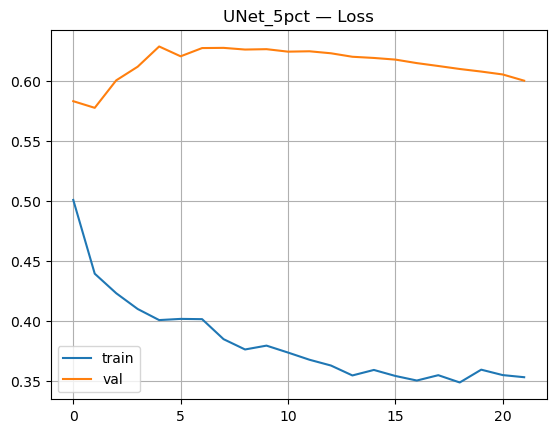

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 634ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 32s 395ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 422ms/step

TRAIN
  Acc=0.7275  Prec=0.6934  Rec=0.1827  MeanIoU=0.4403  Dice=0.2913  HD=9.4484  MyIoU=0.0261  MAE=0.2725

FULL DATASET
  Acc=0.8002  Prec=0.8402  Rec=0.1577  MeanIoU=0.4729  Dice=0.1986  HD=8.6588  MyIoU=0.0176  MAE=0.1998

VALIDATION
  Acc=0.7860  Prec=0.8198  Rec=0.2367  MeanIoU=0.4984  Dice=0.3766  HD=8.1682  MyIoU=0.0259  MAE=0.2140

TEST
  Acc=0.7618  Prec=0.8553  Rec=0.2347  MeanIoU=0.4849  Dice=0.3224  HD=9.1461  MyIoU=0.0363  MAE=0.2382

Training: UNet_10pct  (10% labelled data)

Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.7840 - dice_coeff: 0.5159 - loss: 0.5092 - mean_absolute_error: 0.3873 - mean_io_u: 0.3410 - precision: 0.6483 - recall: 0.7231
Epoch 1: val_loss improved from None to 0.62247, saving model to saved_models\model_UNet_10pct.keras

Epoch 1: finished saving model to saved_mo

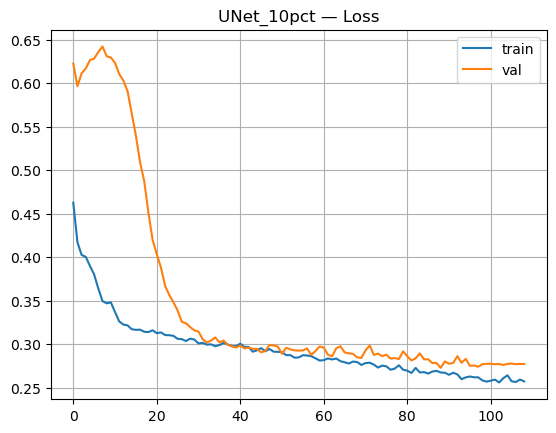

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 476ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 32s 388ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 445ms/step

TRAIN
  Acc=0.9831  Prec=0.9798  Rec=0.9653  MeanIoU=0.9612  Dice=0.9695  HD=3.8421  MyIoU=0.9299  MAE=0.0169

FULL DATASET
  Acc=0.9037  Prec=0.7957  Rec=0.7799  MeanIoU=0.7663  Dice=0.7555  HD=5.8898  MyIoU=0.4712  MAE=0.0963

VALIDATION
  Acc=0.9308  Prec=0.9747  Rec=0.8579  MeanIoU=0.8655  Dice=0.9141  HD=5.4194  MyIoU=0.7135  MAE=0.0692

TEST
  Acc=0.8747  Prec=0.8060  Rec=0.7591  MeanIoU=0.7401  Dice=0.7860  HD=6.4722  MyIoU=0.4202  MAE=0.1253

Training: UNet_20pct  (20% labelled data)
Epoch 1/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.7841 - dice_coeff: 0.5530 - loss: 0.4724 - mean_absolute_error: 0.3705 - mean_io_u: 0.3295 - precision: 0.6556 - recall: 0.8055
Epoch 1: val_loss improved from None to 0.65964, saving model to saved_models\model_UNet_20pct.keras

Epoch 1: finished saving model to saved_mod

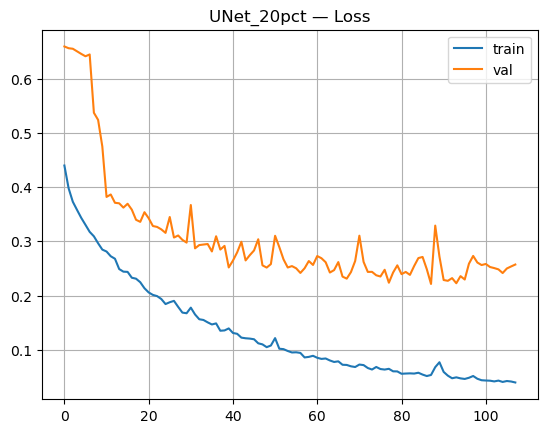

12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 422ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 33s 397ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 441ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 416ms/step

TRAIN
  Acc=0.9923  Prec=0.9883  Rec=0.9890  MeanIoU=0.9830  Dice=0.9864  HD=3.4565  MyIoU=0.9959  MAE=0.0077

FULL DATASET
  Acc=0.9211  Prec=0.7924  Rec=0.8880  MeanIoU=0.8107  Dice=0.7894  HD=5.8601  MyIoU=0.5172  MAE=0.0789

VALIDATION
  Acc=0.9126  Prec=0.7684  Rec=0.9235  MeanIoU=0.8046  Dice=0.7959  HD=6.3669  MyIoU=0.5248  MAE=0.0874

TEST
  Acc=0.8973  Prec=0.8113  Rec=0.8508  MeanIoU=0.7865  Dice=0.8298  HD=6.0987  MyIoU=0.4926  MAE=0.1027

Training: UNet_50pct  (50% labelled data)
Epoch 1/200
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.8028 - dice_coeff: 0.5079 - loss: 0.4999 - mean_absolute_error: 0.3709 - mean_io_u: 0.3593 - precision: 0.6221 - recall: 0.7950
Epoch 1: val_loss improved from None to 0.67233, saving model to saved_models\model_UNet_50pct.keras

Epoch 1: finished saving model to saved

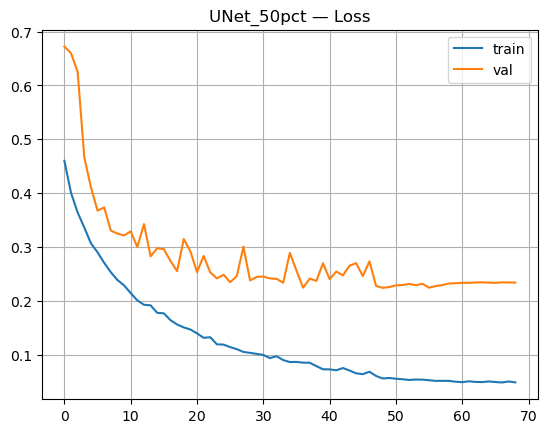

29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 412ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 32s 393ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 369ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 428ms/step

TRAIN
  Acc=0.9867  Prec=0.9768  Rec=0.9759  MeanIoU=0.9678  Dice=0.9686  HD=3.8185  MyIoU=0.9313  MAE=0.0133

FULL DATASET
  Acc=0.9463  Prec=0.8604  Rec=0.9138  MeanIoU=0.8640  Dice=0.8500  HD=5.1044  MyIoU=0.6194  MAE=0.0537

VALIDATION
  Acc=0.9227  Prec=0.8376  Rec=0.8516  MeanIoU=0.8165  Dice=0.8276  HD=5.7101  MyIoU=0.5454  MAE=0.0773

TEST
  Acc=0.9107  Prec=0.8391  Rec=0.8637  MeanIoU=0.8105  Dice=0.8437  HD=5.8728  MyIoU=0.5127  MAE=0.0893

All label fractions complete.


In [12]:
fractions_to_run = [LABEL_FRACTIONS[0]] if TEST_MODE else LABEL_FRACTIONS
FT_EPOCHS = 1 if TEST_MODE else FINETUNE_EPOCHS
FT_BATCH  = 2 if TEST_MODE else FINETUNE_BATCH
TEST_CAP  = 10

all_results = []

for fraction in fractions_to_run:
    pct     = int(fraction * 100)
    keyname = f"UNet_{pct}pct"
    print(f"\n{'='*60}")
    print(f"Training: {keyname}  ({pct}% labelled data)")
    print(f"{'='*60}")

    tf.keras.backend.clear_session()

    # ---- Slice labelled subset ----
    n_labelled = int(X_train.shape[0] * fraction)
    if TEST_MODE:
        n_labelled = min(n_labelled, TEST_CAP)
        print(f"[TEST_MODE] capped to {n_labelled} samples, {FT_EPOCHS} epoch")
    X_subset = X_train[:n_labelled]
    Y_subset = Y_train[:n_labelled]

    # ---- Build model from scratch ----
    model = build_unet(name=keyname)

    # ---- Callbacks ----
    cur_date = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    callbacks = [
        ModelCheckpoint(
            os.path.join(SAVE_DIR, f"model_{keyname}.keras"),
            monitor='val_loss', verbose=1, save_best_only=True
        ),
        ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=10),
        EarlyStopping(monitor='val_loss', verbose=1, patience=20),
        CSVLogger(f"logs/{keyname}_{cur_date}.log"),
        TensorBoard(log_dir=f"logs/fit/{keyname}_{cur_date}", histogram_freq=0),
    ]

    # ---- Compile + Train ----
    model.compile(
        loss=bce_dice_loss,
        optimizer=Adam(),
        metrics=['accuracy', Precision(), MeanIoU(num_classes=2), Recall(),
                 dice_coeff, MeanAbsoluteError()]
    )

    if TRAIN_FLG:
        history = model.fit(
            X_subset, Y_subset,
            validation_split=val_split,
            batch_size=FT_BATCH,
            epochs=FT_EPOCHS,
            callbacks=callbacks
        )
        plt.plot(history.history['loss'],     label='train')
        plt.plot(history.history['val_loss'], label='val')
        plt.title(f"{keyname} — Loss")
        plt.legend()
        plt.grid()
        plt.show()
    else:
        print("Loading saved weights...")
        model.load_weights(os.path.join(SAVE_DIR, f"model_{keyname}.keras"))

    # ---- Evaluate ----
    split_idx  = int(X_subset.shape[0] * (1 - val_split))
    X_tr_split = X_subset[:split_idx]
    Y_tr_split = Y_subset[:split_idx]
    X_val      = X_subset[split_idx:]
    Y_val      = Y_subset[split_idx:]

    preds_train = (model.predict(X_tr_split, verbose=1) > THRESHOLD).astype(np.float32)
    preds_full  = (model.predict(X_train,    verbose=1) > THRESHOLD).astype(np.float32)
    preds_val   = (model.predict(X_val,      verbose=1) > THRESHOLD).astype(np.float32)
    preds_test  = (model.predict(X_test,     verbose=1) > THRESHOLD).astype(np.float32)

    print("\nTRAIN")
    train_m = evalResult(Y_tr_split.astype(np.float32), preds_train)
    print("\nFULL DATASET")
    full_m  = evalResult(Y_train.astype(np.float32),    preds_full)
    print("\nVALIDATION")
    val_m   = evalResult(Y_val.astype(np.float32),      preds_val)
    print("\nTEST")
    test_m  = evalResult(Y_test.astype(np.float32),     preds_test)

    row = {"Model": keyname, "Label Fraction (%)": pct}
    for split_name, metrics in [("Train", train_m), ("Full", full_m),
                                  ("Val", val_m), ("Test", test_m)]:
        for k, v in metrics.items():
            row[f"{split_name} {k}"] = v
    all_results.append(row)

print("\nAll label fractions complete.")

## Results Table

In [13]:
results_df = pd.DataFrame(all_results)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

print("\n================ FINAL RESULTS ================\n")
display(results_df)

results_df.to_csv(os.path.join(SAVE_DIR, "unet_results.csv"), index=False)
print("Saved to unet_results.csv")


================ FINAL RESULTS ================



,Model,Label Fraction (%),Train Accuracy,Train Precision,Train Recall,Train MeanIoU,Train Dice,Train HD,Train MyIoU,Train MAE,Full Accuracy,Full Precision,Full Recall,Full MeanIoU,Full Dice,Full HD,Full MyIoU,Full MAE,Val Accuracy,Val Precision,Val Recall,Val MeanIoU,Val Dice,Val HD,Val MyIoU,Val MAE,Test Accuracy,Test Precision,Test Recall,Test MeanIoU,Test Dice,Test HD,Test MyIoU,Test MAE
0,UNet_5pct,5,0.7275,0.6934,0.1827,0.4403,0.2913,9.4484,0.0261,0.2725,0.8002,0.8402,0.1577,0.4729,0.1986,8.6588,0.0176,0.1998,0.7860,0.8198,0.2367,0.4984,0.3766,8.1682,0.0259,0.2140,0.7618,0.8553,0.2347,0.4849,0.3224,9.1461,0.0363,0.2382
1,UNet_10pct,10,0.9831,0.9798,0.9653,0.9612,0.9695,3.8421,0.9299,0.0169,0.9037,0.7957,0.7799,0.7663,0.7555,5.8898,0.4712,0.0963,0.9308,0.9747,0.8579,0.8655,0.9141,5.4194,0.7135,0.0692,0.8747,0.8060,0.7591,0.7401,0.7860,6.4722,0.4202,0.1253
2,UNet_20pct,20,0.9923,0.9883,0.9890,0.9830,0.9864,3.4565,0.9959,0.0077,0.9211,0.7924,0.8880,0.8107,0.7894,5.8601,0.5172,0.0789,0.9126,0.7684,0.9235,0.8046,0.7959,6.3669,0.5248,0.0874,0.8973,0.8113,0.8508,0.7865,0.8298,6.0987,0.4926,0.1027
3,UNet_50pct,50,0.9867,0.9768,0.9759,0.9678,0.9686,3.8185,0.9313,0.0133,0.9463,0.8604,0.9138,0.8640,0.8500,5.1044,0.6194,0.0537,0.9227,0.8376,0.8516,0.8165,0.8276,5.7101,0.5454,0.0773,0.9107,0.8391,0.8637,0.8105,0.8437,5.8728,0.5127,0.0893


Saved to unet_results.csv


## Qualitative Visualisation

In [ ]:
# Reload the best model (50% fraction) for visualisation
best_model = tf.keras.models.load_model(
    os.path.join(SAVE_DIR, "model_UNet_50pct.keras"), compile=False
)
preds_test_vis = (best_model.predict(X_test, verbose=0) > THRESHOLD).astype(np.float32)

sample_idx = [0, 1, 2]
fig, axes  = plt.subplots(len(sample_idx), 3, figsize=(12, 4 * len(sample_idx)))
for row, ix in enumerate(sample_idx):
    axes[row, 0].imshow(X_test[ix].astype('uint8'));               axes[row, 0].set_title('Image');     axes[row, 0].axis('off')
    axes[row, 1].imshow(np.squeeze(Y_test[ix]), cmap='gray');      axes[row, 1].set_title('GT Mask');   axes[row, 1].axis('off')
    axes[row, 2].imshow(np.squeeze(preds_test_vis[ix]), cmap='gray'); axes[row, 2].set_title('Predicted'); axes[row, 2].axis('off')
plt.tight_layout()
plt.show()